Connect to dataset on google drive

In [ ]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import all reqired libraries
import os
import cv2
import json
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import Xception
%matplotlib inline
np.random.seed(2)
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
from keras.preprocessing.image import img_to_array
from keras.preprocessing.image import load_img


In [ ]:
import os
import cv2
import shutil
import gc
import re
import json
from pylab import *
from PIL import Image, ImageChops, ImageEnhance
import scipy
import scipy.misc
from scipy import ndimage
import skimage.io
import skimage.filters
import sys

train_frame_folder = '/content/drive/MyDrive/FAFV'
output_folder = '/content/drive/MyDrive/FAFV_frames'
moved_folder = '/content/drive/MyDrive/FAFV_moved'


list_of_train_data = [f for f in os.listdir(train_frame_folder) if f.endswith('.mp4')]


for vid in list_of_train_data:
  get_max_emotions_and_save_frames(vid, train_frame_folder, output_folder)

# Close all OpenCV windows
cv2.destroyAllWindows()

Load the frames extracted from the four folders into four arrays with a shape of 128 * 128, and perform flattening and normalization by dividing each pixel value by 256.

In [ ]:
input_shape = (128, 128, 3)

real_data = [f for f in os.listdir('/content/drive/MyDrive/RARV_frames/') if f.endswith('.png')]
real_data_2 = [f for f in os.listdir('/content/drive/MyDrive/FARV_frames/') if f.endswith('.png')]

fake_data = [f for f in os.listdir('/content/drive/MyDrive/RAFV_frames/') if f.endswith('.png')]
fake_data_2 = [f for f in os.listdir('/content/drive/MyDrive/FAFV_frames/') if f.endswith('.png')]

X=[]
Y=[]
ctr=0

for img in real_data:
    X.append(img_to_array(load_img('/content/drive/MyDrive/RARV_frames/'+img)).flatten() / 255.0)
    Y.append(1)
    ctr+=1

for img in real_data_2:
    X.append(img_to_array(load_img('/content/drive/MyDrive/FARV_frames/'+img)).flatten() / 255.0)
    Y.append(1)
    ctr+=1

for img in fake_data:
    X.append(img_to_array(load_img('/content/drive/MyDrive/RAFV_frames/'+img)).flatten() / 255.0)
    Y.append(0)
    ctr+=1

for img in fake_data_2:
    X.append(img_to_array(load_img('/content/drive/MyDrive/FAFV_frames/'+img)).flatten() / 255.0)
    Y.append(0)
    ctr+=1

#Normalization
X = np.array(X)
Y = np.array(Y)

#Reshape
X = X.reshape(-1, 128, 128, 3)



In [ ]:
#Train-Test split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.25, random_state=42, stratify=Y)



In next 2 cells, in FakeAVCeleb dataset, real samples are minority class so we oversample real samples by extracting real samples then implementing data augmentation techniques on them, including rotation, shear, zoom, horizontal flip, fill mode, brightness adjustment, and channel shift.

In [ ]:
from sklearn.utils import resample

# Assuming X_train is your image data and Y_train is the corresponding labels

# Find indices of real samples
real_indices = np.where(Y_train == 1)[0]

# Extract real samples
X_real = X_train[real_indices]
Y_real = Y_train[real_indices]

# Find indices of fake samples
fake_indices = np.where(Y_train == 0)[0]

# Extract fake samples
X_fake = X_train[fake_indices]
Y_fake = Y_train[fake_indices]

# Resample the real samples to match the number of fake samples
X_real_oversampled, Y_real_oversampled = resample(X_real, Y_real, replace=True, n_samples=len(X_fake), random_state=42)

# Create the ImageDataGenerator with augmentations
datagen = ImageDataGenerator(
    rotation_range=10,       # Small rotations
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7, 1.3],  # Brightness adjustment
    channel_shift_range=10,     # Hue randomization
)

# Fit the generator on the oversampled real data
datagen.fit(X_real_oversampled)

In [ ]:

# Combine oversampled real samples with original fake samples
X_train = np.concatenate([X_real_oversampled, X_fake])
Y_train = np.concatenate([Y_real_oversampled, Y_fake])

# Shuffle the oversampled data
shuffle_indices = np.random.permutation(len(X_train))
X_train = X_train[shuffle_indices]
Y_train = Y_train[shuffle_indices]


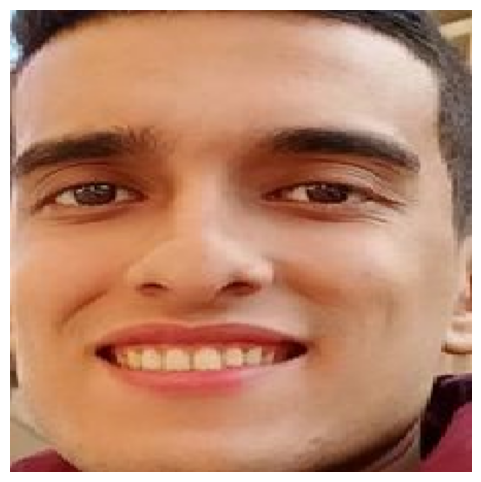

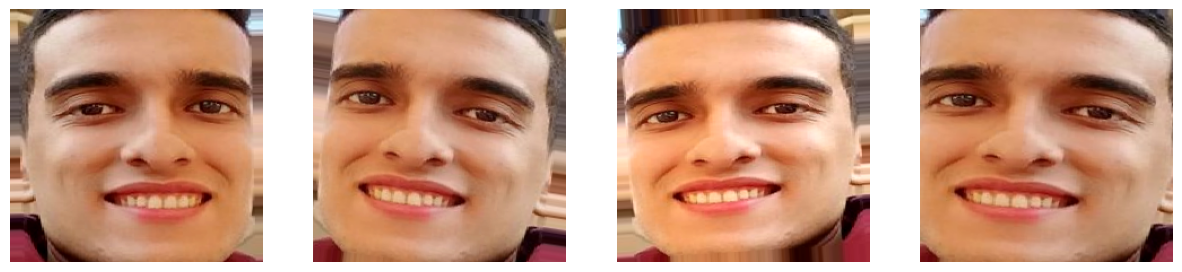

In [ ]:
# only an example of data augmentation on one frame

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing.image import ImageDataGenerator


# Load an example image from your Google Drive
# Replace 'path_to_your_image' with the actual path to your image file
img_path = '/content/drive/MyDrive/my_image.jpg'
img = image.load_img(img_path, target_size=(224, 224))  # Adjust target_size as needed
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Create the ImageDataGenerator with augmentations
datagen = ImageDataGenerator(
    rotation_range=10,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7, 1.3],
    channel_shift_range=10,
)

# Visualize the original image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# Generate augmented images
augmented_images = []
for batch in datagen.flow(img_array, batch_size=1):
    augmented_images.append(image.array_to_img(batch[0]))
    if len(augmented_images) >= 4:  # Adjust the number of augmented images to display
        break

# Visualize augmented images
plt.figure(figsize=(15, 6))
for i, augmented_img in enumerate(augmented_images):
    plt.subplot(1, len(augmented_images), i + 1)
    plt.imshow(augmented_img)
    plt.axis('off')
plt.show()


In this phase, the model is constructed utilizing the Xception pre-trained architecture. The top layers are excluded, retaining only the base layers of the Xception model. Fine-tuning is performed on the initial 50 layers of the Xception model, while the subsequent layers remain frozen. A fully connected layer with 128 neurons and a rectified linear unit (ReLU) activation function is added, followed by dropout with a rate of 0.7. Finally, an output layer with a single neuron and a sigmoid activation function is appended to the model.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import ModelCheckpoint
from keras.callbacks import LearningRateScheduler

# Load the pretrained Xception model without the top classification layer
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the layers in the base model
xception_base.trainable = True

# Choose the layers you want to fine-tune
fine_tune_at = 50  # Adjust this value based on the architecture of Xception
for layer in xception_base.layers[:fine_tune_at]:
    layer.trainable = False

# Create the model
model = keras.Sequential([
    xception_base,
    keras.layers.GlobalAveragePooling2D(),
    Dropout(0.7),
    keras.layers.Dense(128, activation='relu'),
    Dropout(0.7),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(lr=.000001), loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=0,
                               patience=15,
                               verbose=0, mode='auto', restore_best_weights=True)


# Train the model with early stopping and model checkpoint
history = model.fit(X_train, Y_train,
                    batch_size=32,
                    epochs=50,
                    validation_data=(X_val, Y_val),
                    callbacks=[early_stopping]
                    )

Epoch 1/50
50/50 [==============================] - 24s 162ms/step - loss: 0.2633 - accuracy: 0.9346 - val_loss: 1.9484 - val_accuracy: 0.9524
Epoch 2/50
50/50 [==============================] - 7s 138ms/step - loss: 0.1218 - accuracy: 0.9524 - val_loss: 0.6477 - val_accuracy: 0.9524
Epoch 3/50
50/50 [==============================] - 7s 138ms/step - loss: 0.0705 - accuracy: 0.9619 - val_loss: 0.4783 - val_accuracy: 0.9543
Epoch 4/50
50/50 [==============================] - 6s 124ms/step - loss: 0.0339 - accuracy: 0.9803 - val_loss: 0.2590 - val_accuracy: 0.9714
Epoch 5/50
50/50 [==============================] - 7s 134ms/step - loss: 0.0431 - accuracy: 0.9835 - val_loss: 2.0334 - val_accuracy: 0.9676
Epoch 6/50
50/50 [==============================] - 7s 131ms/step - loss: 0.0505 - accuracy: 0.9867 - val_loss: 1.1075 - val_accuracy: 0.7352
Epoch 7/50
50/50 [==============================] - 6s 120ms/step - loss: 0.0506 - accuracy: 0.9816 - val_loss: 0.2706 - val_accuracy: 0.9657
Epoch

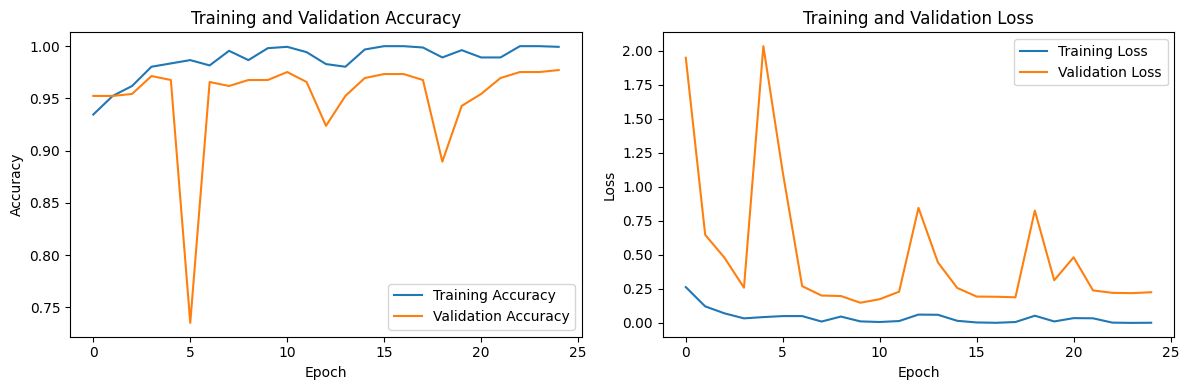

In [ ]:

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()

In [ ]:
# Save the entire model to a file after training
model.save("/content/drive/MyDrive/epochs_50_layers__32__20_aug_new_model.h5")